In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek
import itertools

In [2]:
files = ['two_class_raw_1s_no.csv', 'two_class_raw_1s_yo_0.5.csv', 'two_class_raw_1s_yo_0.8.csv', 'two_class_raw_2s_no.csv', 'two_class_raw_2s_yo_0.5.csv', 'two_class_raw_2s_yo_0.8.csv', 
        'two_class_raw_3s_no.csv', 'two_class_raw_3s_yo_0.5.csv', 'two_class_raw_3s_yo_0.8.csv', 'two_class_raw_4s_no.csv', 'two_class_raw_4s_yo_0.5.csv', 'two_class_raw_4s_yo_0.8.csv',
        'two_class_raw_5s_no.csv', 'two_class_raw_5s_yo_0.5.csv', 'two_class_raw_5s_yo_0.8.csv']

base_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/improved_features_data_main/'

In [3]:
class_names = ['void', 'non-void']

In [4]:
def generate_confusion_matrix(cnf_matrix, classes, normalize=False, title='Confusion matrix'):
    plt.imshow(cnf_matrix, interpolation='nearest', cmap=plt.get_cmap())
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cnf_matrix.max() / 2.

    for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
        plt.text(j, i, format(cnf_matrix[i, j], fmt), horizontalalignment="center",
                color="black" if cnf_matrix[i, j] > thresh else "yellow")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    return cnf_matrix

In [5]:
def plot_confusion_matrix(predicted_labels_list, y_test_list, strategy_name, exp_name):
    cnf_matrix = confusion_matrix(y_test_list, predicted_labels_list, labels=class_names)
    np.set_printoptions(precision=2)

    # Plot non-normalized confusion matrix
    plt.figure()
    generate_confusion_matrix(cnf_matrix, classes=class_names, title=f'RandomForest - {exp_name}({strategy_name})')
    file_name = f'cv-cm_{exp_name}_{strategy_name}.png'
    plt.savefig(f'/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/RandomForest/cv-conf-mat_entire/{file_name}')
    plt.show()

In [6]:
def compare_sampling_techniques(X, y, groups, exp_name, random_state=42):
    """
    Compare different sampling techniques for imbalanced classification
    """
    
    # Define sampling strategies to test
    sampling_strategies = {
        'none': None,
        'oversample_smote': SMOTE(random_state=random_state),
        'undersample_tomek_links': TomekLinks(),
        'combined_smote_tomek': SMOTETomek(random_state=random_state)
    }
    
    results = {}
    
    for strategy_name, sampler in sampling_strategies.items():
        print(f"\nTesting {strategy_name}...")
        
        # Cross-validation setup
        gkf = GroupKFold(n_splits=10) 
        fold_results = []
        
        # For confusion matrix
        predicted_targets = np.array([])
        actual_targets = np.array([])
        
        for fold_num, (train_idx_fold, test_idx_fold) in enumerate(gkf.split(X, y, groups)):
            X_train_fold, X_test_fold = X.iloc[train_idx_fold], X.iloc[test_idx_fold]
            y_train_fold, y_test_fold = y.iloc[train_idx_fold], y.iloc[test_idx_fold]

            
            # Apply sampling (if any)
            if sampler is not None:
                try:
                    X_train_resampled, y_train_resampled = sampler.fit_resample(X_train_fold, y_train_fold)
                    X_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train_fold.columns)
                    y_train_resampled = pd.Series(y_train_resampled)
                except Exception as e:
                    print(f"Sampling failed for {strategy_name}: {e}")
                    continue
            else:
                X_train_resampled = X_train_fold
                y_train_resampled = y_train_fold
            

            # Use RandomForest with DEFAULT parameters
            model = RandomForestClassifier(
                random_state=random_state,
            )
            
            # Encode labels
            label_encoder = LabelEncoder()
            y_train_encoded = label_encoder.fit_transform(y_train_resampled)
            
            # Fit model
            model.fit(X_train_resampled, y_train_encoded)
            
            # Predict
            predictions = label_encoder.inverse_transform(model.predict(X_test_fold))
            
            # For confusion matrix
            predicted_targets = np.append(predicted_targets, predictions)
            actual_targets = np.append(actual_targets, y_test_fold)
        plot_confusion_matrix(predicted_targets, actual_targets,strategy_name, exp_name)

Generating confusion matrices from the cross validation results:   0%|          | 0/15 [00:00<?, ?it/s]

Analysing 1s_no

Testing none...


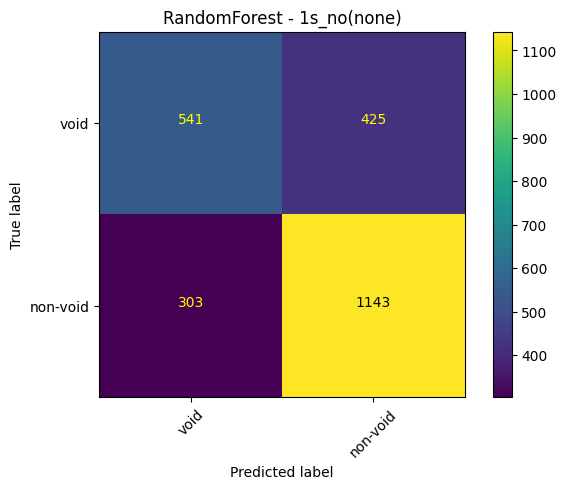


Testing oversample_smote...


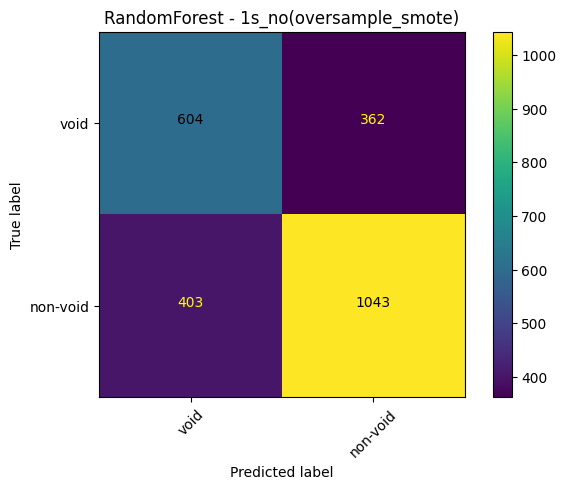


Testing undersample_tomek_links...


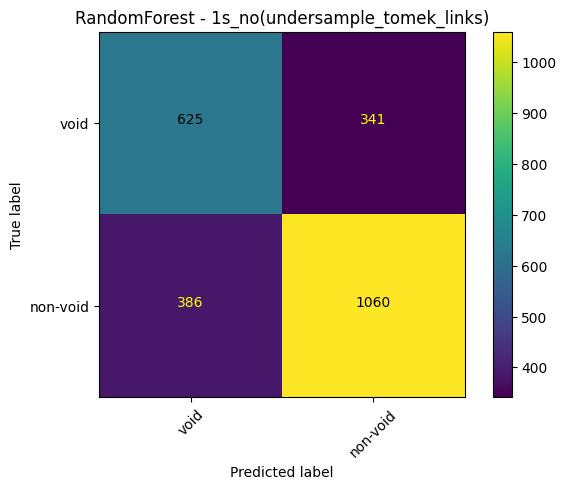


Testing combined_smote_tomek...


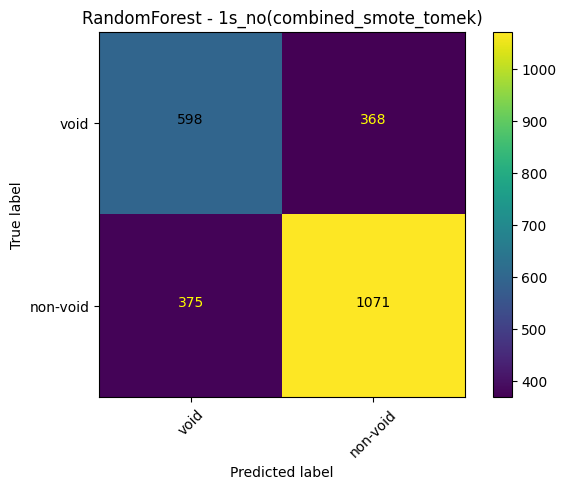

Generating confusion matrices from the cross validation results:   7%|▋         | 1/15 [01:17<18:09, 77.80s/it]

Analysing 1s_0.5

Testing none...


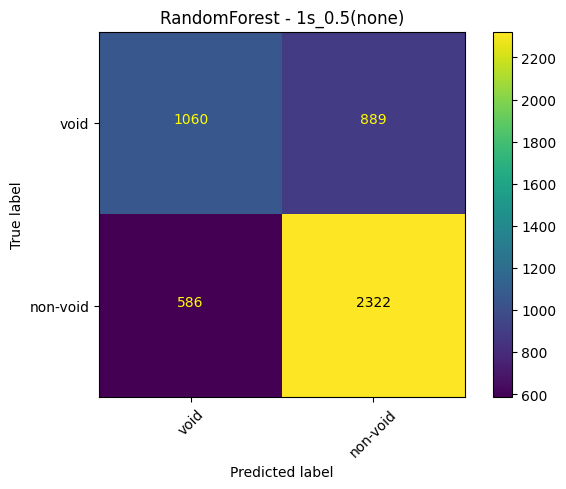


Testing oversample_smote...


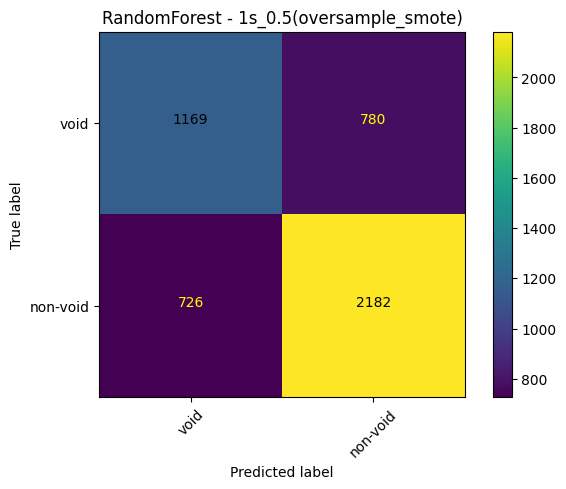


Testing undersample_tomek_links...


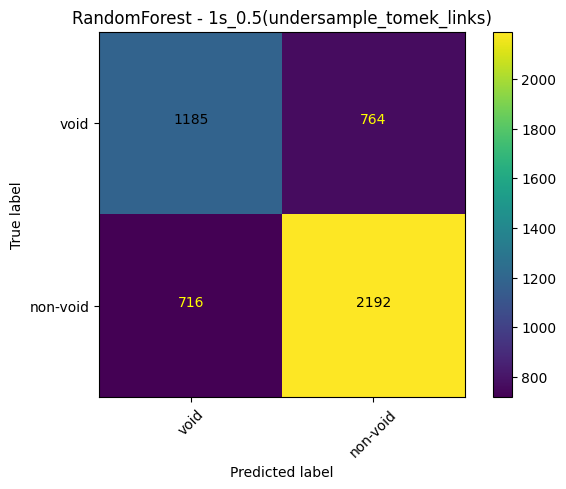


Testing combined_smote_tomek...


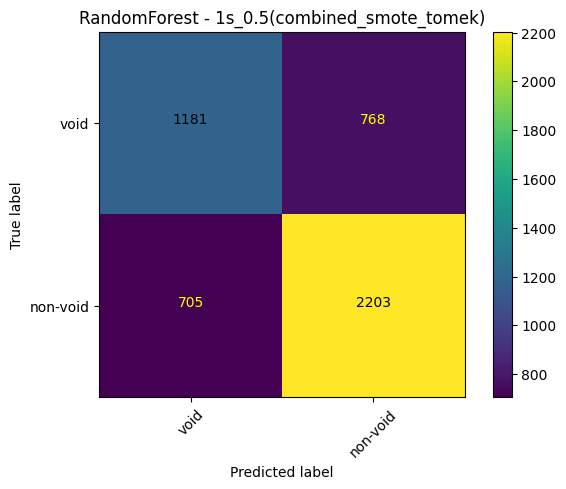

Generating confusion matrices from the cross validation results:  13%|█▎        | 2/15 [04:08<28:38, 132.16s/it]

Analysing 1s_0.8

Testing none...


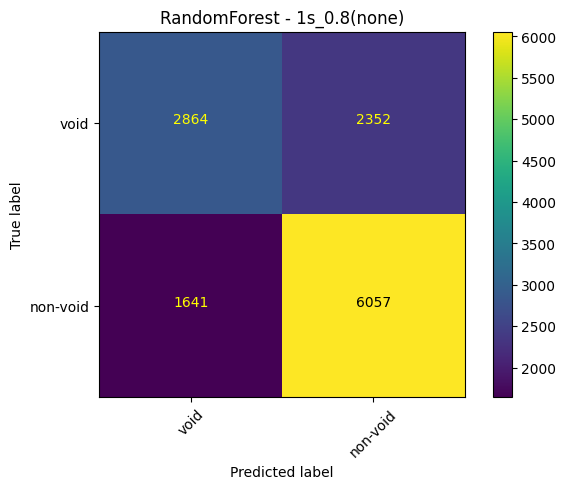


Testing oversample_smote...


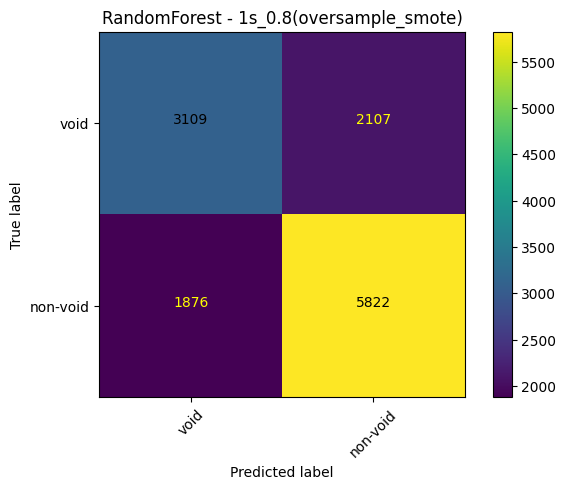


Testing undersample_tomek_links...


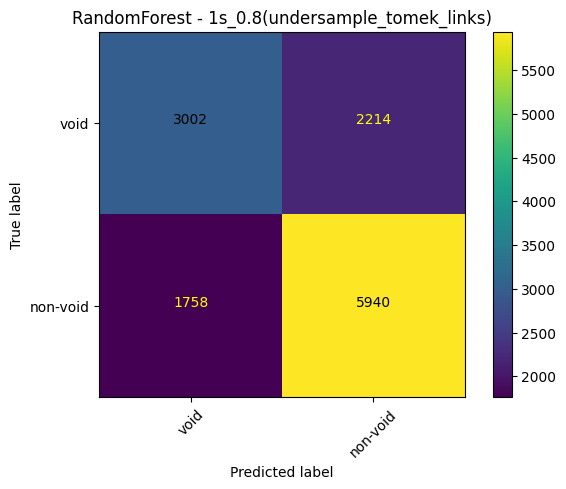


Testing combined_smote_tomek...


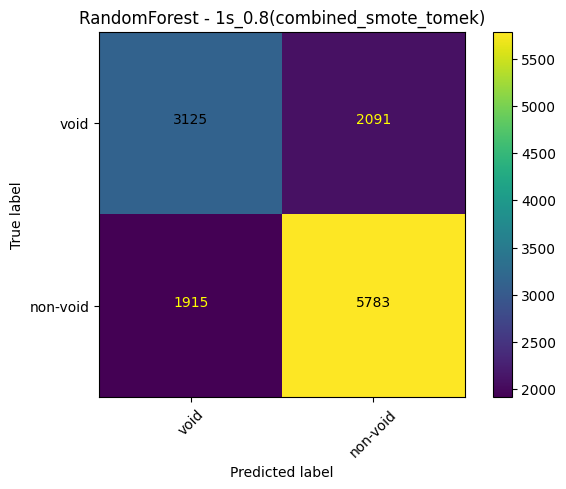

Generating confusion matrices from the cross validation results:  20%|██        | 3/15 [13:05<1:03:29, 317.42s/it]

Analysing 2s_no

Testing none...


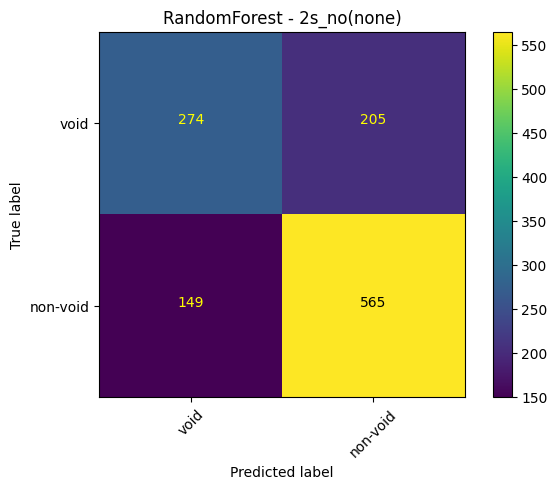


Testing oversample_smote...


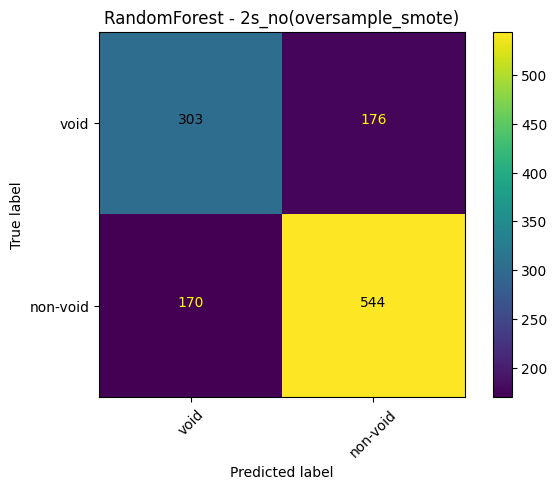


Testing undersample_tomek_links...


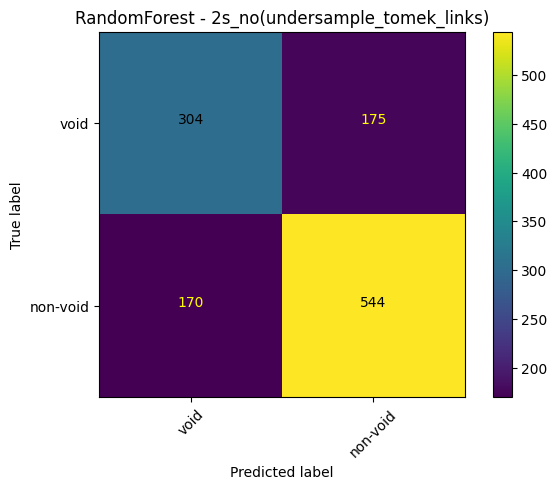


Testing combined_smote_tomek...


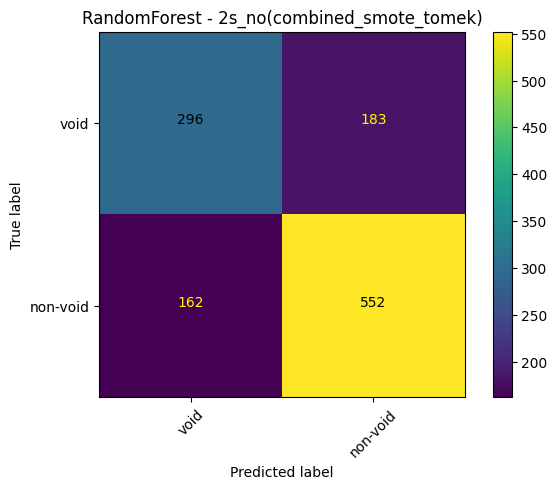

Generating confusion matrices from the cross validation results:  27%|██▋       | 4/15 [13:41<37:48, 206.27s/it]  

Analysing 2s_0.5

Testing none...


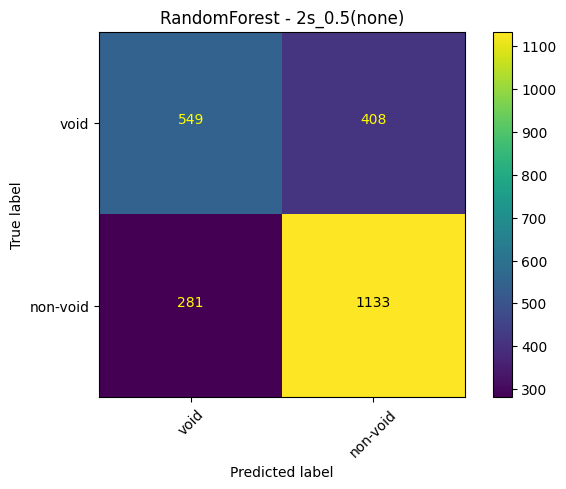


Testing oversample_smote...


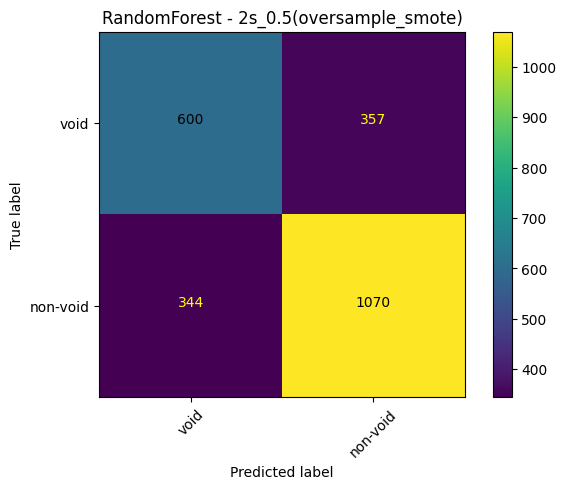


Testing undersample_tomek_links...


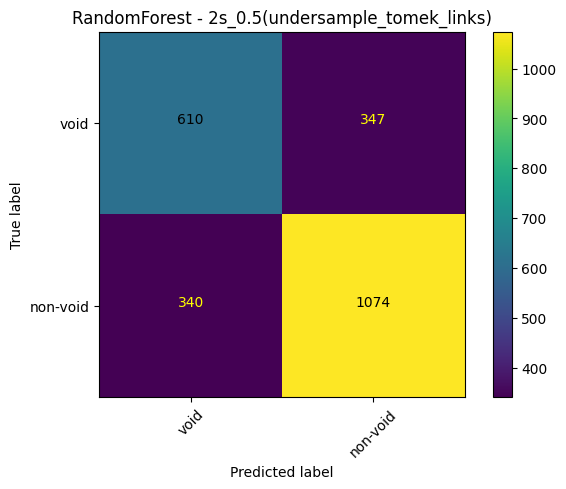


Testing combined_smote_tomek...


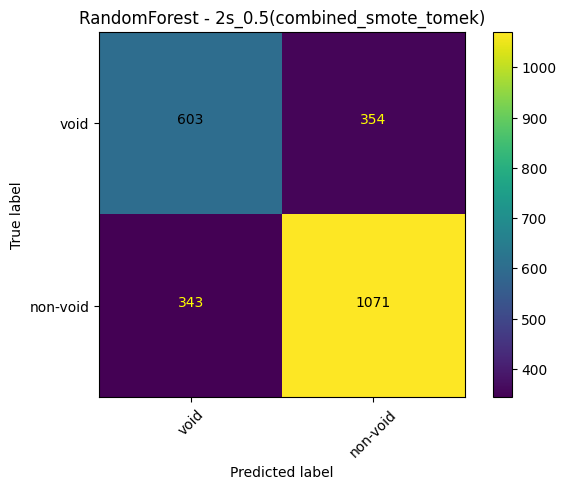

Generating confusion matrices from the cross validation results:  33%|███▎      | 5/15 [14:58<26:35, 159.52s/it]

Analysing 2s_0.8

Testing none...


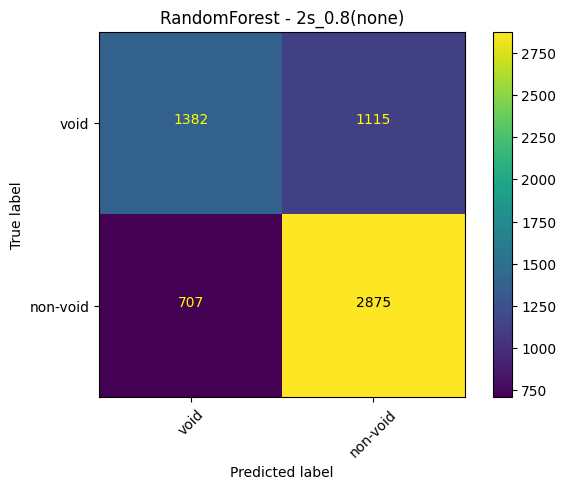


Testing oversample_smote...


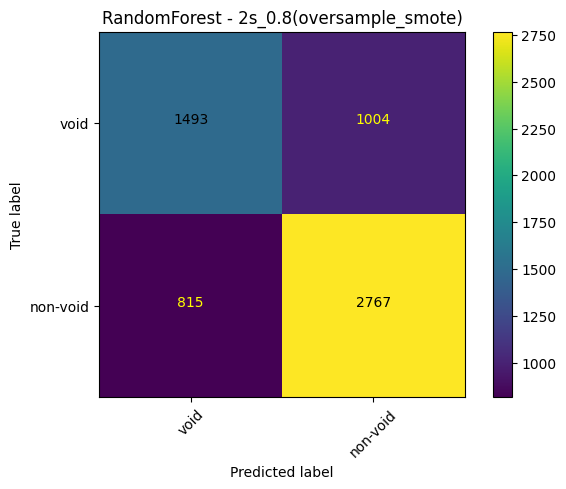


Testing undersample_tomek_links...


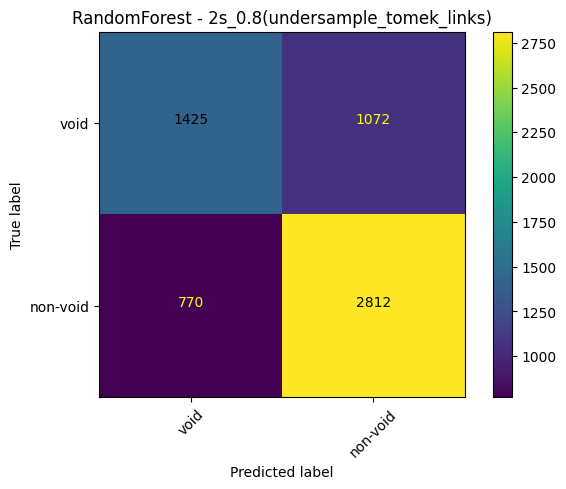


Testing combined_smote_tomek...


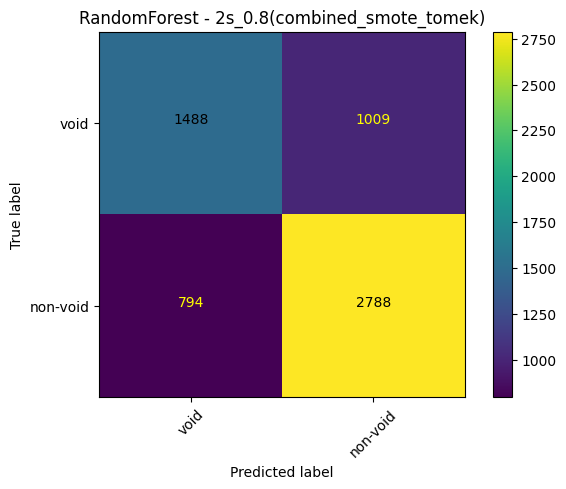

Generating confusion matrices from the cross validation results:  40%|████      | 6/15 [18:43<27:17, 181.95s/it]

Analysing 3s_no

Testing none...


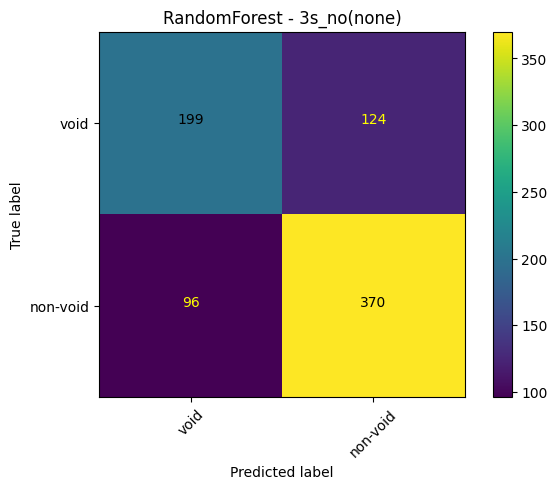


Testing oversample_smote...


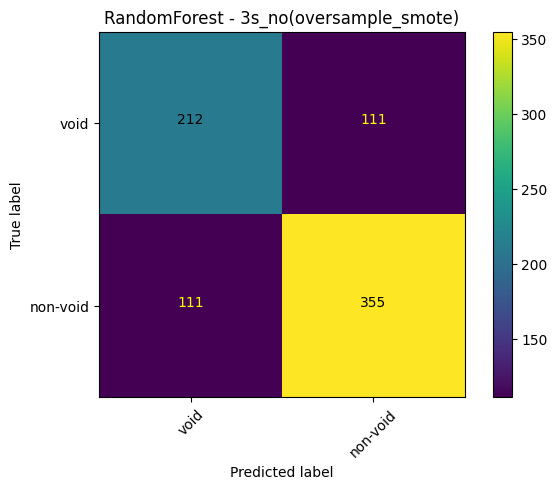


Testing undersample_tomek_links...


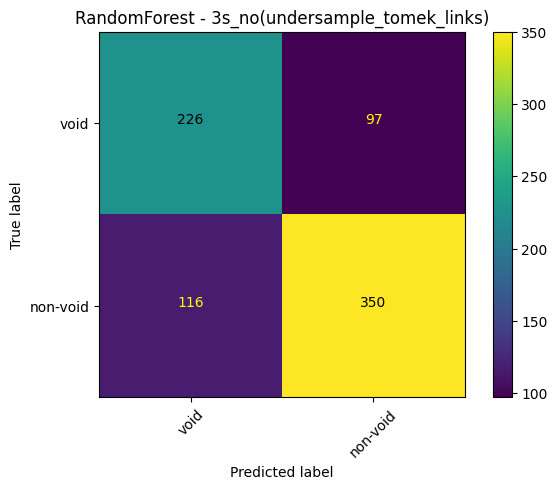


Testing combined_smote_tomek...


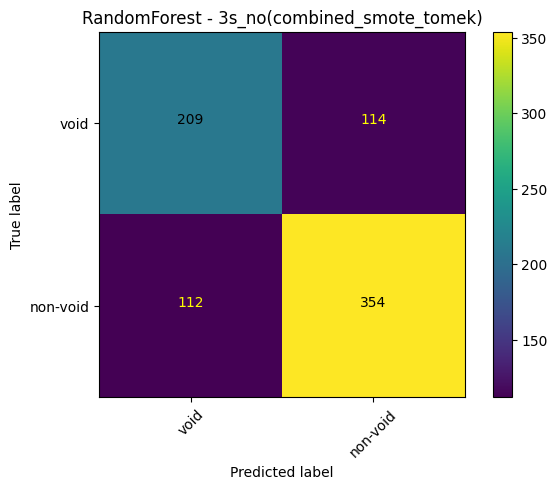

Generating confusion matrices from the cross validation results:  47%|████▋     | 7/15 [19:06<17:19, 129.90s/it]

Analysing 3s_0.5

Testing none...


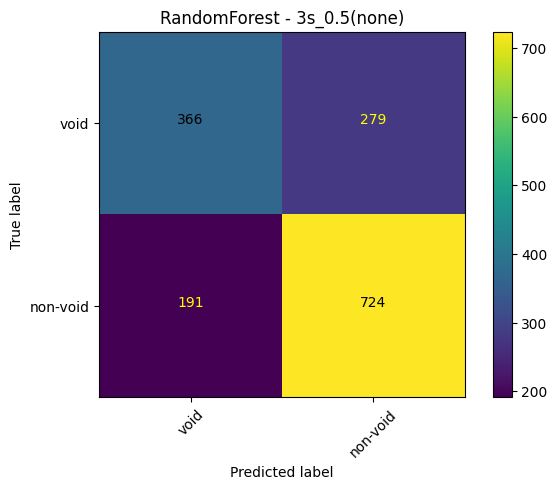


Testing oversample_smote...


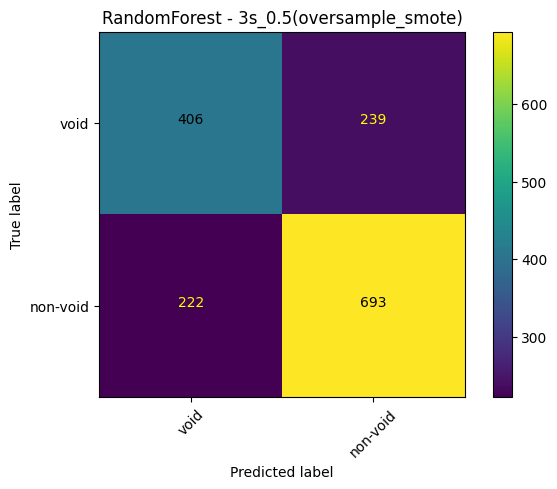


Testing undersample_tomek_links...


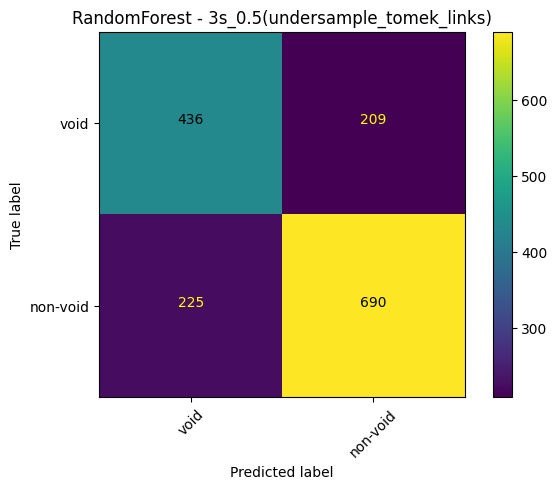


Testing combined_smote_tomek...


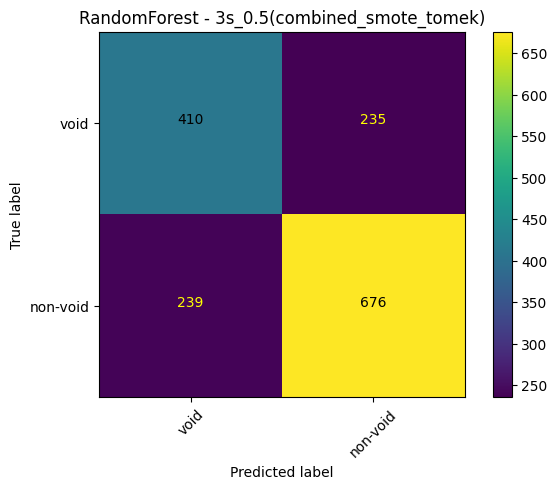

Generating confusion matrices from the cross validation results:  53%|█████▎    | 8/15 [19:54<12:06, 103.78s/it]

Analysing 3s_0.8

Testing none...


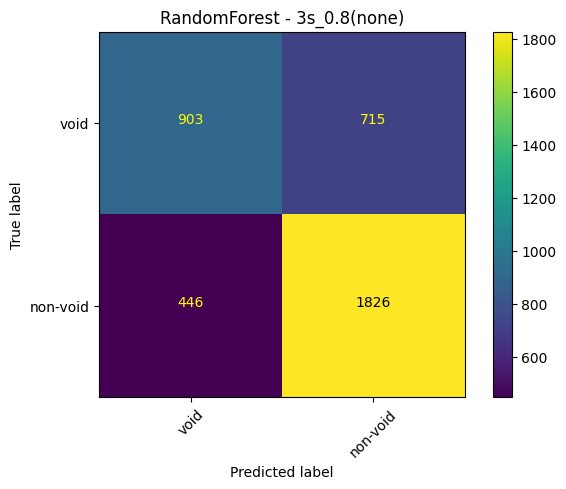


Testing oversample_smote...


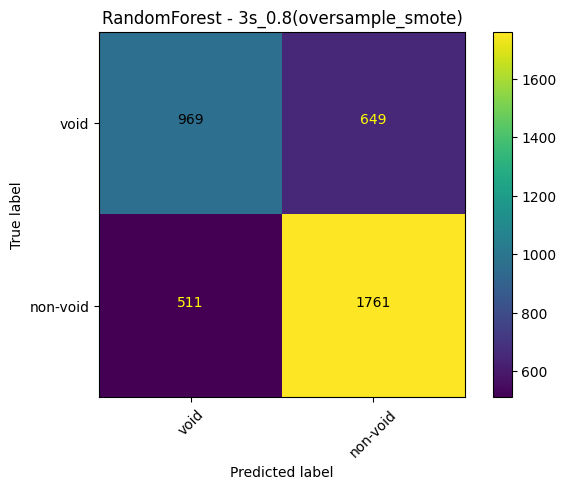


Testing undersample_tomek_links...


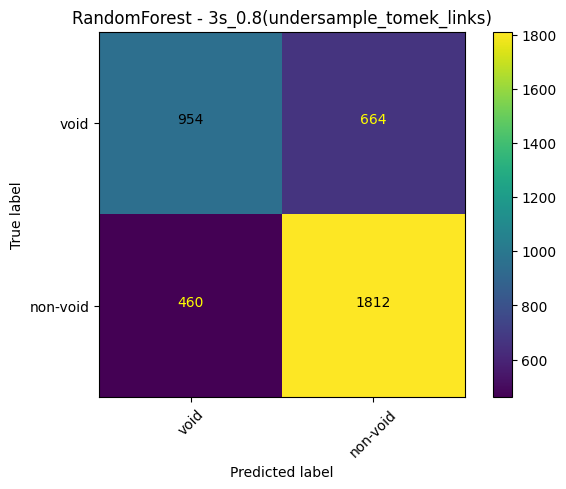


Testing combined_smote_tomek...


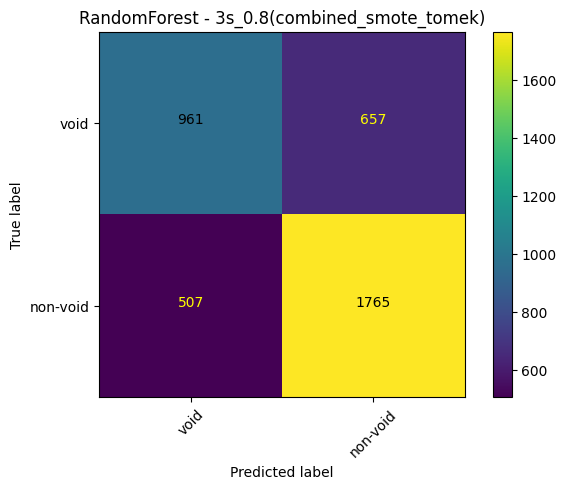

Generating confusion matrices from the cross validation results:  60%|██████    | 9/15 [22:10<11:24, 114.01s/it]

Analysing 4s_no

Testing none...


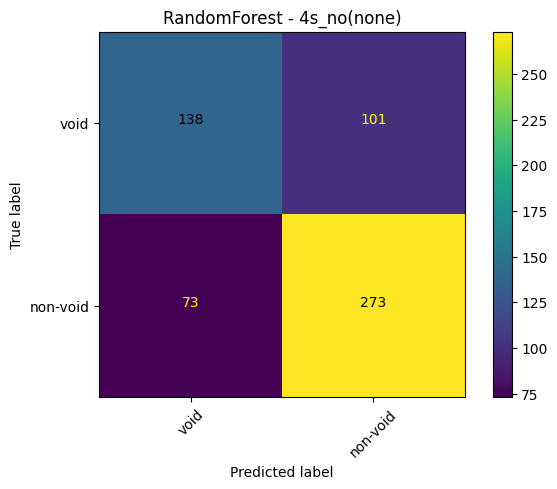


Testing oversample_smote...


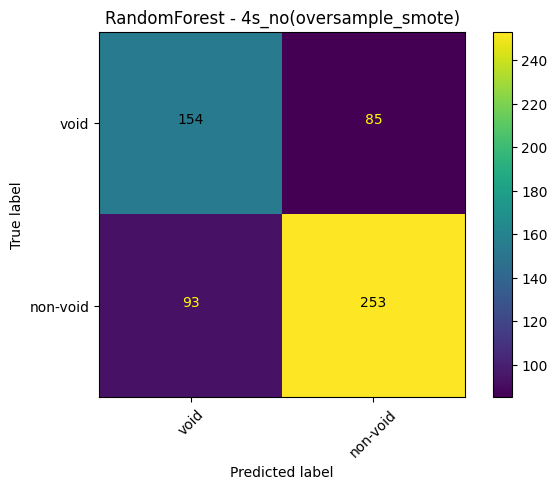


Testing undersample_tomek_links...


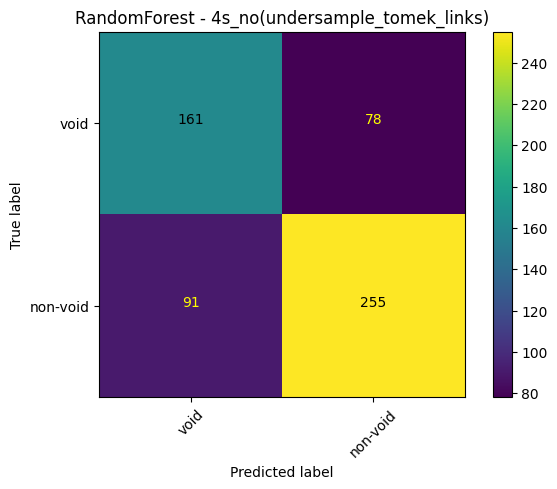


Testing combined_smote_tomek...


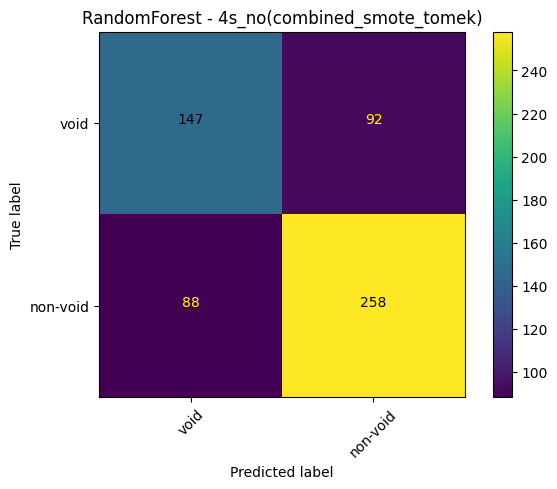

Generating confusion matrices from the cross validation results:  67%|██████▋   | 10/15 [22:28<07:01, 84.28s/it]

Analysing 4s_0.5

Testing none...


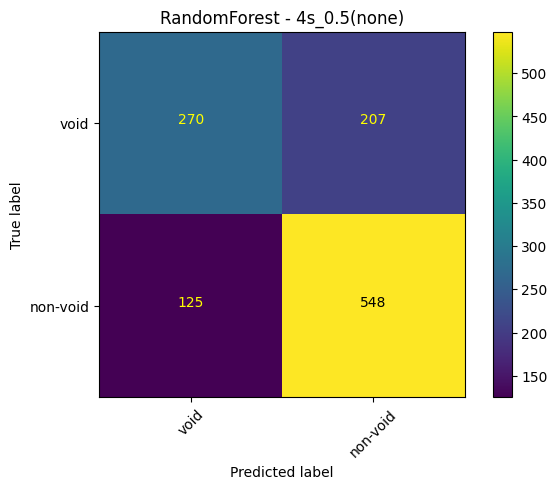


Testing oversample_smote...


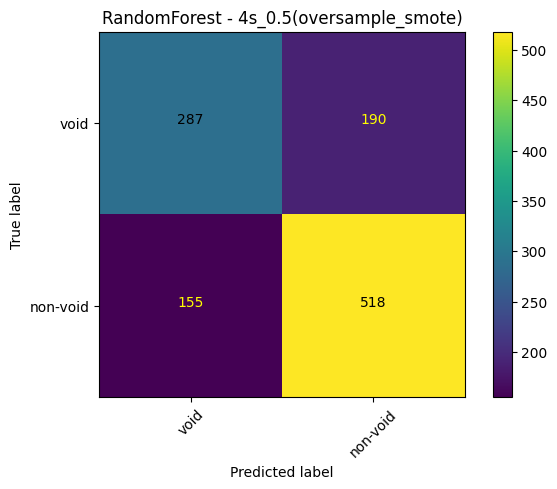


Testing undersample_tomek_links...


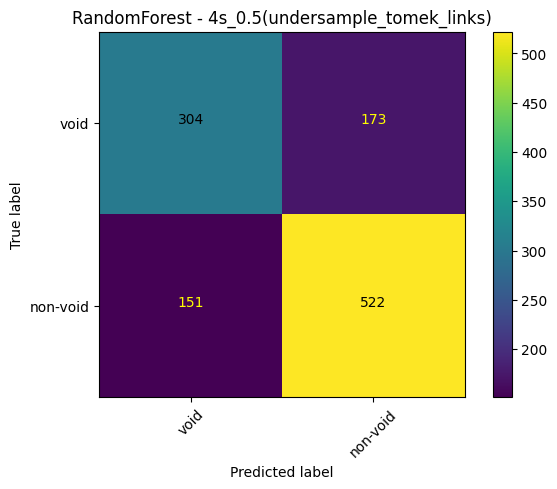


Testing combined_smote_tomek...


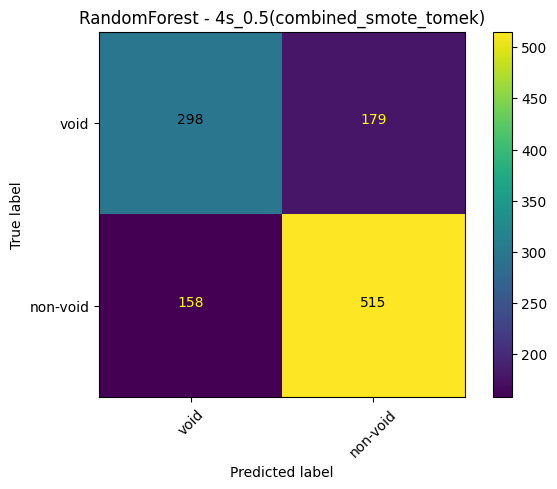

Generating confusion matrices from the cross validation results:  73%|███████▎  | 11/15 [23:03<04:36, 69.13s/it]

Analysing 4s_0.8

Testing none...


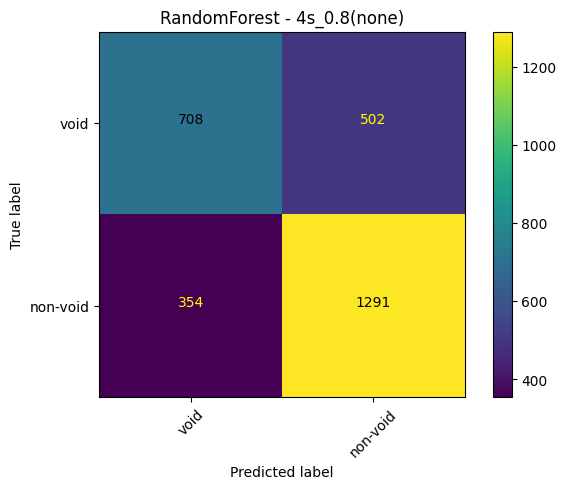


Testing oversample_smote...


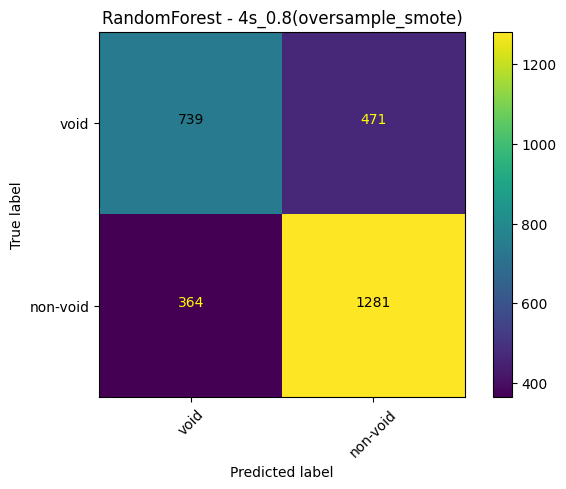


Testing undersample_tomek_links...


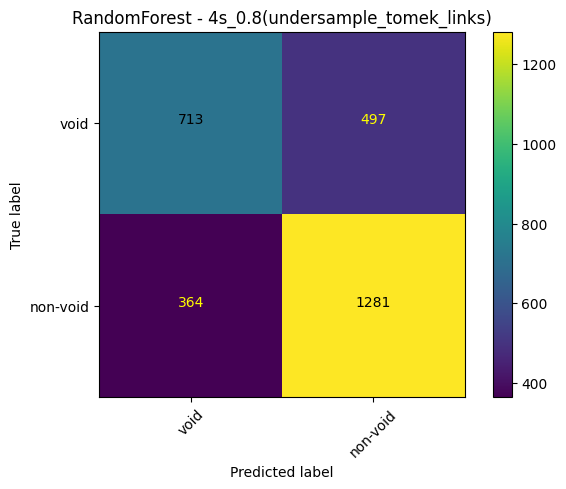


Testing combined_smote_tomek...


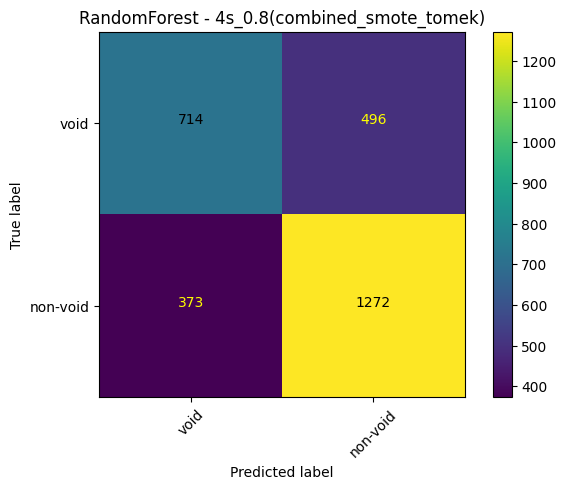

Generating confusion matrices from the cross validation results:  80%|████████  | 12/15 [24:33<03:46, 75.54s/it]

Analysing 5s_no

Testing none...


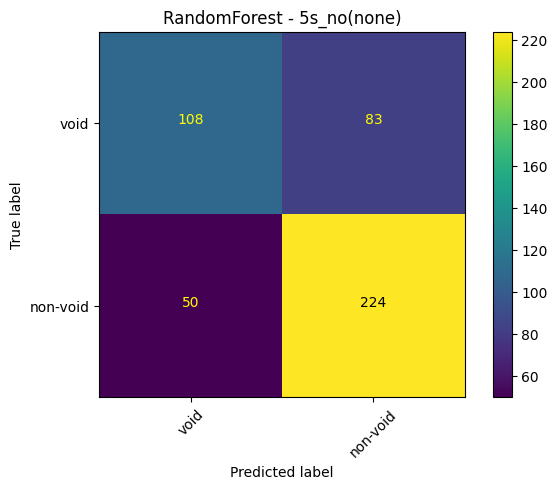


Testing oversample_smote...


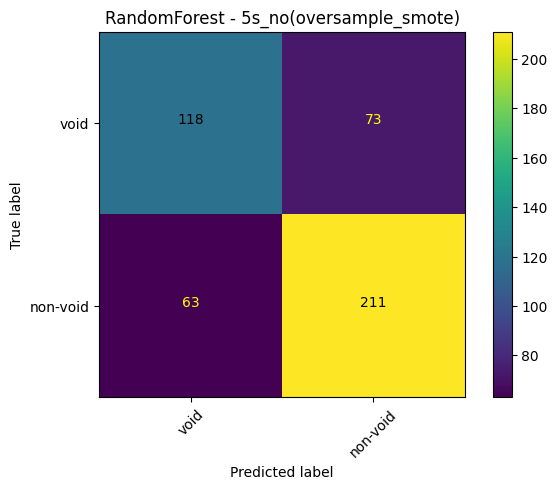


Testing undersample_tomek_links...


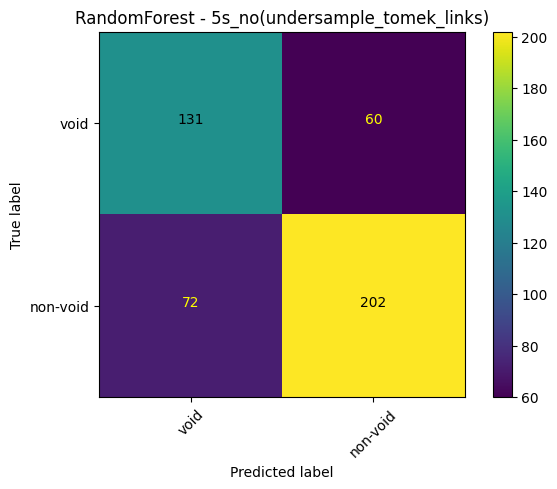


Testing combined_smote_tomek...


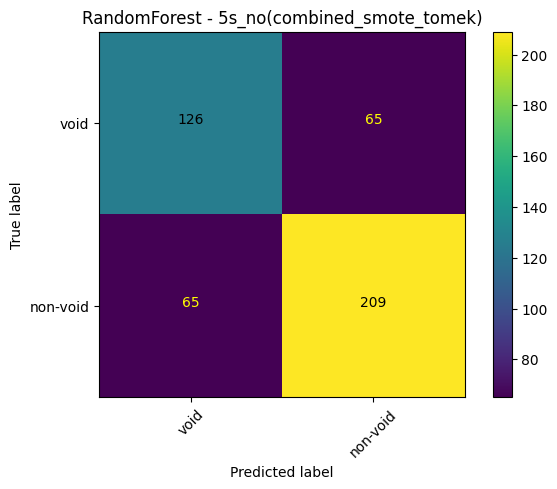

Generating confusion matrices from the cross validation results:  87%|████████▋ | 13/15 [24:46<01:52, 56.46s/it]

Analysing 5s_0.5

Testing none...


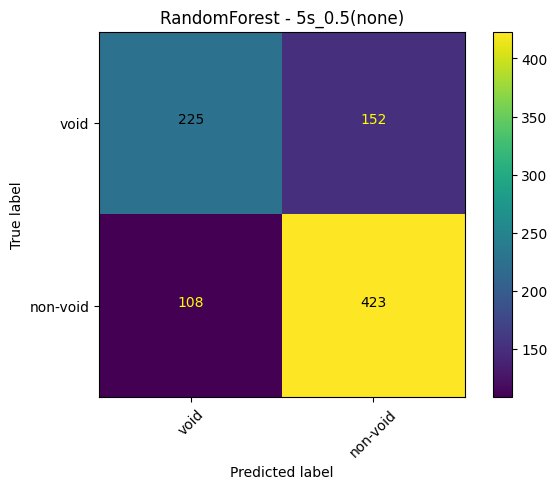


Testing oversample_smote...


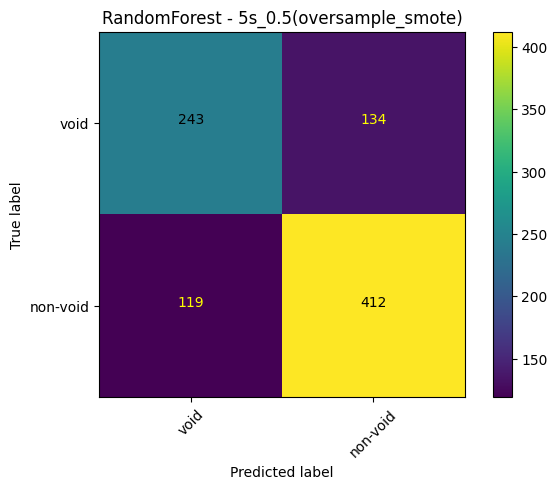


Testing undersample_tomek_links...


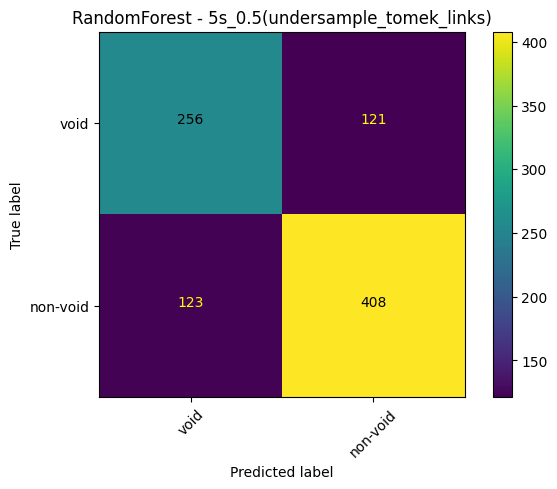


Testing combined_smote_tomek...


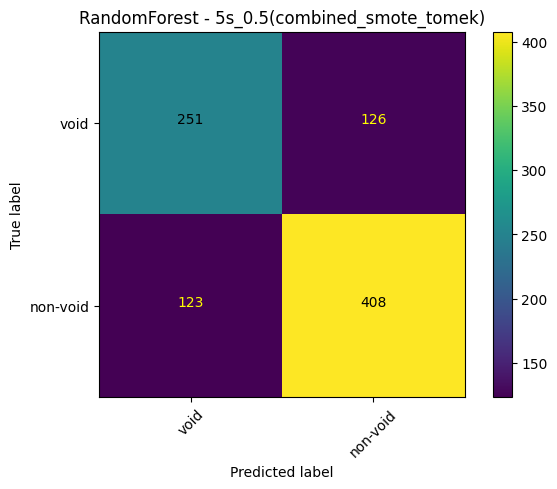

Generating confusion matrices from the cross validation results:  93%|█████████▎| 14/15 [25:09<00:46, 46.57s/it]

Analysing 5s_0.8

Testing none...


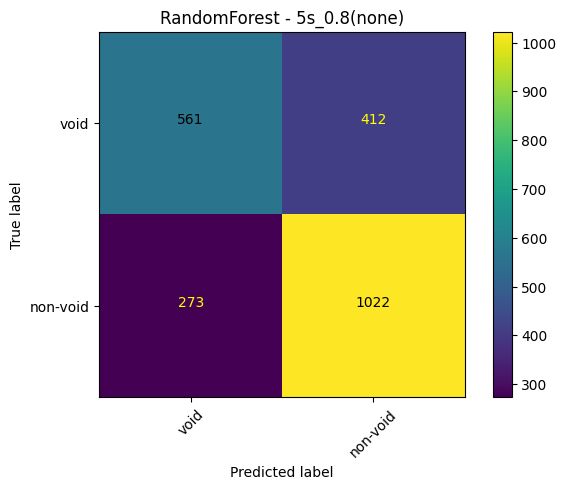


Testing oversample_smote...


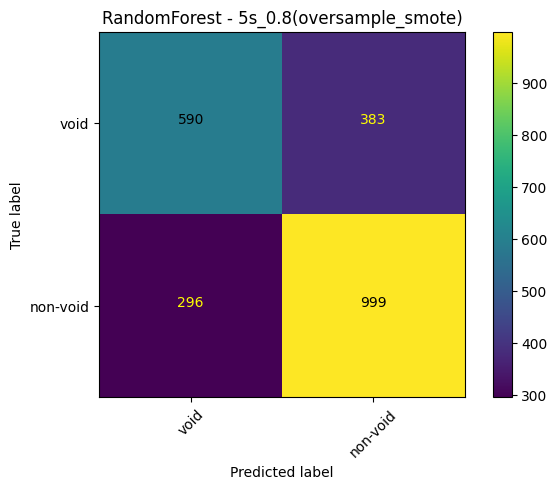


Testing undersample_tomek_links...


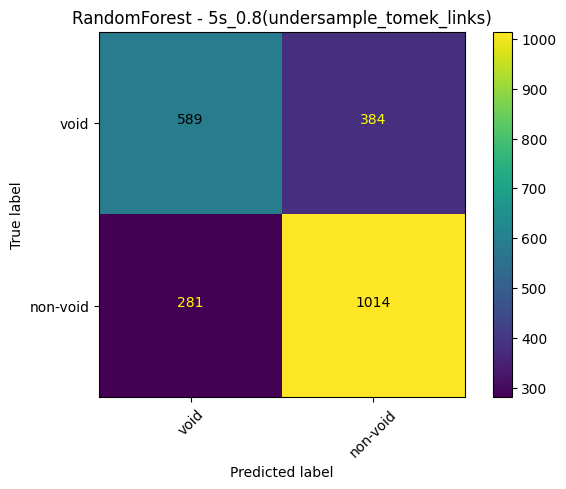


Testing combined_smote_tomek...


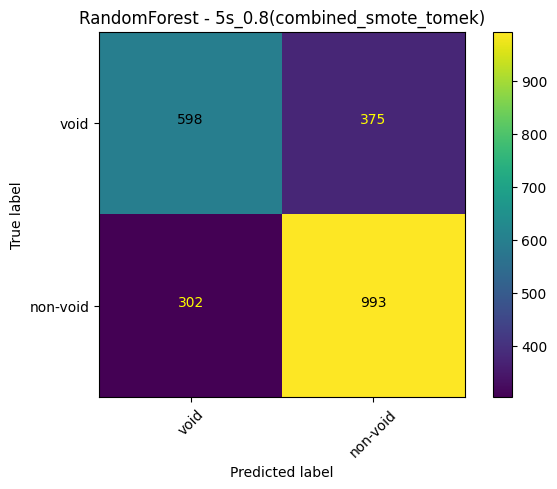

Generating confusion matrices from the cross validation results: 100%|██████████| 15/15 [26:13<00:00, 104.89s/it]


In [7]:
file_results = {}
for file in tqdm(files, desc="Generating confusion matrices from the cross validation results"):
    data_path = os.path.join(base_path, file)
    features = pd.read_csv(data_path)
    features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)
    details = file.split('_')
    exp_name = f"{details[3]}_{details[-1].replace('.csv', '')}"
    print(f"Analysing {exp_name}")
    
    # split data
    X = features.drop(columns=['label', 'experiment_id'])
    y = features['label']
    groups = features['experiment_id']
    
    compare_sampling_techniques(X, y, groups, exp_name, 42)

### Classification report

In [11]:
def print_classification_report(y_test, y_pred, strategy_name, exp_name):
    report = classification_report(y_test, y_pred, labels=class_names)

    print(f'Classification report: RandomForest {exp_name}({strategy_name})')
    print(report)

In [12]:
def compare_sampling_techniques_classification_report(X, y, groups, exp_name, random_state=42):
    """
    Compare different sampling techniques for imbalanced classification
    """
    
    # Define sampling strategies to test
    sampling_strategies = {
        'none': None,
        'oversample_smote': SMOTE(random_state=random_state),
        'undersample_tomek_links': TomekLinks(),
        'combined_smote_tomek': SMOTETomek(random_state=random_state)
    }
    
    results = {}
    
    for strategy_name, sampler in sampling_strategies.items():
        print(f"\nTesting {strategy_name}...")
        
        # Cross-validation setup
        gkf = GroupKFold(n_splits=10) 
        fold_results = []
        
        # For confusion matrix
        predicted_targets = np.array([])
        actual_targets = np.array([])
        
        for fold_num, (train_idx_fold, test_idx_fold) in enumerate(gkf.split(X, y, groups)):
            X_train_fold, X_test_fold = X.iloc[train_idx_fold], X.iloc[test_idx_fold]
            y_train_fold, y_test_fold = y.iloc[train_idx_fold], y.iloc[test_idx_fold]

            
            # Apply sampling (if any)
            if sampler is not None:
                try:
                    X_train_resampled, y_train_resampled = sampler.fit_resample(X_train_fold, y_train_fold)
                    X_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train_fold.columns)
                    y_train_resampled = pd.Series(y_train_resampled)
                except Exception as e:
                    print(f"Sampling failed for {strategy_name}: {e}")
                    continue
            else:
                X_train_resampled = X_train_fold
                y_train_resampled = y_train_fold
            
            # Use RandomForest with DEFAULT parameters
            model = RandomForestClassifier(
                random_state=random_state
            )
            
            # Encode labels
            label_encoder = LabelEncoder()
            y_train_encoded = label_encoder.fit_transform(y_train_resampled)
            
            # Fit model
            model.fit(X_train_resampled, y_train_encoded)
            
            # Predict
            predictions = label_encoder.inverse_transform(model.predict(X_test_fold))
            
            # For confusion matrix
            predicted_targets = np.append(predicted_targets, predictions)
            actual_targets = np.append(actual_targets, y_test_fold)
        print_classification_report(predicted_targets, actual_targets,strategy_name, exp_name)

In [13]:
file_results = {}
for file in tqdm(files, desc="Generating classification reports from the cross validation results"):
    data_path = os.path.join(base_path, file)
    features = pd.read_csv(data_path)
    features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)
    details = file.split('_')
    exp_name = f"{details[3]}_{details[-1].replace('.csv', '')}"
    print(f"Analysing {exp_name}")
    
    # split data
    X = features.drop(columns=['label', 'experiment_id'])
    y = features['label']
    groups = features['experiment_id']
    
    compare_sampling_techniques_classification_report(X, y, groups, exp_name, 42)

Generating classification reports from the cross validation results:   0%|          | 0/15 [00:00<?, ?it/s]

Analysing 1s_no

Testing none...
Classification report: RandomForest 1s_no(none)
              precision    recall  f1-score   support

        void       0.56      0.64      0.60       844
    non-void       0.79      0.73      0.76      1568

    accuracy                           0.70      2412
   macro avg       0.68      0.68      0.68      2412
weighted avg       0.71      0.70      0.70      2412


Testing oversample_smote...
Classification report: RandomForest 1s_no(oversample_smote)
              precision    recall  f1-score   support

        void       0.63      0.60      0.61      1007
    non-void       0.72      0.74      0.73      1405

    accuracy                           0.68      2412
   macro avg       0.67      0.67      0.67      2412
weighted avg       0.68      0.68      0.68      2412


Testing undersample_tomek_links...
Classification report: RandomForest 1s_no(undersample_tomek_links)
              precision    recall  f1-score   support

        void      

Generating classification reports from the cross validation results:   7%|▋         | 1/15 [01:17<18:04, 77.45s/it]

Classification report: RandomForest 1s_no(combined_smote_tomek)
              precision    recall  f1-score   support

        void       0.62      0.61      0.62       973
    non-void       0.74      0.74      0.74      1439

    accuracy                           0.69      2412
   macro avg       0.68      0.68      0.68      2412
weighted avg       0.69      0.69      0.69      2412

Analysing 1s_0.5

Testing none...
Classification report: RandomForest 1s_0.5(none)
              precision    recall  f1-score   support

        void       0.54      0.64      0.59      1646
    non-void       0.80      0.72      0.76      3211

    accuracy                           0.70      4857
   macro avg       0.67      0.68      0.67      4857
weighted avg       0.71      0.70      0.70      4857


Testing oversample_smote...
Classification report: RandomForest 1s_0.5(oversample_smote)
              precision    recall  f1-score   support

        void       0.60      0.62      0.61      1895


Generating classification reports from the cross validation results:  13%|█▎        | 2/15 [04:13<29:22, 135.59s/it]

...

Classification report: RandomForest 5s_no(combined_smote_tomek)
              precision    recall  f1-score   support

        void       0.66      0.66      0.66       191
    non-void       0.76      0.76      0.76       274

    accuracy                           0.72       465
   macro avg       0.71      0.71      0.71       465
weighted avg       0.72      0.72      0.72       465

Analysing 5s_0.5

Testing none...
Classification report: RandomForest 5s_0.5(none)
              precision    recall  f1-score   support

        void       0.60      0.68      0.63       333
    non-void       0.80      0.74      0.76       575

    accuracy                           0.71       908
   macro avg       0.70      0.71      0.70       908
weighted avg       0.72      0.71      0.72       908


Testing oversample_smote...
Classification report: RandomForest 5s_0.5(oversample_smote)
              precision    recall  f1-score   support

        void       0.64      0.67      0.66       362


Generating classification reports from the cross validation results:  93%|█████████▎| 14/15 [24:30<00:43, 43.71s/it]

Classification report: RandomForest 5s_0.5(combined_smote_tomek)
              precision    recall  f1-score   support

        void       0.67      0.67      0.67       374
    non-void       0.77      0.76      0.77       534

    accuracy                           0.73       908
   macro avg       0.72      0.72      0.72       908
weighted avg       0.73      0.73      0.73       908

Analysing 5s_0.8

Testing none...
Classification report: RandomForest 5s_0.8(none)
              precision    recall  f1-score   support

        void       0.58      0.67      0.62       834
    non-void       0.79      0.71      0.75      1434

    accuracy                           0.70      2268
   macro avg       0.68      0.69      0.68      2268
weighted avg       0.71      0.70      0.70      2268


Testing oversample_smote...
Classification report: RandomForest 5s_0.8(oversample_smote)
              precision    recall  f1-score   support

        void       0.61      0.67      0.63       886

Generating classification reports from the cross validation results: 100%|██████████| 15/15 [25:34<00:00, 102.27s/it]

Classification report: RandomForest 5s_0.8(combined_smote_tomek)
              precision    recall  f1-score   support

        void       0.61      0.66      0.64       900
    non-void       0.77      0.73      0.75      1368

    accuracy                           0.70      2268
   macro avg       0.69      0.70      0.69      2268
weighted avg       0.71      0.70      0.70      2268

